In [1]:
import warnings
warnings.filterwarnings("ignore")
from test_multicommodity import test_main, create_forcing, plot_result
from mcopt_misc import plot_network, run_mcopt
import sys
sys.path.append('../src/')
import numpy as np
from mcopt import McOpt, paris_topology
from typing import Dict, List, Tuple
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def constrcut_mcopt(beta: float=1.0, n=30, alpha=1, betaw=0.25, L=1.0):
    waxman_config = {"n": n, "alpha": alpha, "beta": betaw, "L": L}
    method, coupling, museed, pflux, rho = "synth", "l1", 0, beta, 0.0   
    time_step, tot_time, relax_linsys, tau_cond_dyn, tau_cost_dyn = 0.5, 10000, 1.0e-5, 1.0e-1, 1.0e-1
    tau_cond_opt, tau_cost_opt = 1.0e-1, 1.0e-1
    VERBOSE = False
    mcopt = McOpt("synth", coupling, museed, pflux, VERBOSE, rho, relax_linsys, tau_cond_dyn, tau_cost_dyn, time_step, tot_time, tau_cond_opt, tau_cost_opt, waxman_config)
    mcopt.ot_setup()
    return mcopt

In [3]:
def compare_mcopt_admk(beta: float=1.0, n=30, alpha=1, betaw=0.25, L=1.0):
    mcopt = constrcut_mcopt(beta, n, alpha, betaw, L)
    forcing, conductivity_mcopt = run_mcopt(mcopt)
    topo, weights, forcing_ = mcopt.export_setup()
    potentials, conductivity_admk, potentials_admk = test_main(topo.copy(), weights, len(forcing_[0]), forcing_, beta=beta, max_iter=25)
    plot_network(mcopt.g, forcing, conductivity_mcopt, conductivity_admk)
    return mcopt.g, forcing_

We only include the <ins>triangular lattice</ins> as the rectangular lattice topolgy is too restricted. 

In [4]:
def discretize_triangular(graph: nx.Graph, forcing: List[np.ndarray], mesh_size=17, beta=1, max_iter=20, n=30, alpha=1, betaw=0.25, L=1.0):
    X_SCALE, Y_SCALE = mesh_size - 1, (mesh_size - 1) * (np.sqrt(3) / 2)
    mesh = nx.triangular_lattice_graph(mesh_size, mesh_size * 2)
    num_commodity = len(mesh.nodes()) 
    nodes_list = list(mesh.nodes())          
    key_to_index = {key: idx for idx, key in enumerate(nodes_list)}
    idx_to_key = {idx: key for key, idx in key_to_index.items()}
    
    def coordinate_to_key(coord):
        y = int(coord[1] / (np.sqrt(3) / 2) + 0.5)
        x = round(coord[0]) if y % 2 == 0 else round(coord[0] - 0.5)
        return (x, y)

    forcing_grid = [np.zeros(num_commodity) for _ in range(len(mesh.nodes()))]
    node_to_index = {}
    for node in graph.nodes:
        raw_pos = (graph.nodes[node]["pos"][0] * X_SCALE, graph.nodes[node]["pos"][1] * Y_SCALE)
        key = coordinate_to_key(raw_pos)
        index = key_to_index[key]
        node_to_index[node] = index
    for node in graph.nodes:
        for comm in range(len(graph.nodes)):
            forcing_grid[node_to_index[node]][node_to_index[comm]] += forcing[node][comm]
    for node in mesh.nodes():
        mesh.nodes[node]["amplitude"] = np.linalg.norm(forcing_grid[key_to_index[node]])
    edge_lists = np.array([list((key_to_index[e[0]], key_to_index[e[1]])) for e in mesh.edges()])
    weights = np.ones_like(edge_lists[:,0])
    potentials, conductivity_admk, energy = test_main(edge_lists, weights, num_commodity, forcing_grid, beta=beta, max_iter=max_iter)
    plt.show()
    pos = {n: (n[0], n[1]) for n in mesh.nodes()}
    nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_admk) * 0.2,  edge_color='C0', style='solid')
    amps = [mesh.nodes[n]['amplitude']  for n in mesh.nodes()]
    nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
    plt.title(f"Triangular Lattice Approximation with Waxman Parameter: n = {n}, alpha = {alpha}, beta = {betaw}, L = {L} | Energy = {energy}")
    plt.show()
    return mesh, conductivity_admk 

In [5]:
def experiment_waxman_triangular_lattice(beta=1, n=30, alpha=1, betaw=0.25, L=1.0):
    graph, forcing = compare_mcopt_admk(beta=beta, n=n, alpha=alpha, betaw=betaw, L=L)
    discretize_triangular(graph, forcing, beta=beta, n=n, alpha=alpha, betaw=betaw, L=L)

* graph topology construction
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0010 max(res)=7.4e-09 max(pres)=6.4e-07
   1.31e+01<=UPDATE<=2.04e+03, deltat=1.96e-03
ierr=0 avg_it=0010 max(res)=9.9e-09 max(pres)=9.6e-07
it=1 var=1.87e+02
   8.75e+00<=UPDATE<=9.64e+02, deltat=2.01e-02
ierr=0 avg_it=0012 max(res)=8.7e-09 max(pres)=7.5e-07
it=2 var=3.52e+01
   1.75e+00<=UPDATE<=2.60e+02, deltat=1.00e-01
ierr=0 avg_it=0012 max(res)=9.6e-09 max(pres)=6.6e-07
it=3 var=5.36e+00
   -1.18e+00<=UPDATE<=9.83e+01, deltat=1.00e-01
ierr=0 avg_it=0011 max(res)=9.7e-09 max(pres)=8.1e-07
it=4 var=1.65e+00
   -1.63e+00<=UPDATE<=6.69e+01, deltat=1.00e-01
ierr=0 avg_it=0011 max(res)=8.5e-09 max(pres)=7.9e-07
it=5 var=1.02e+00
   -1.76e+00<=UPDATE<=4

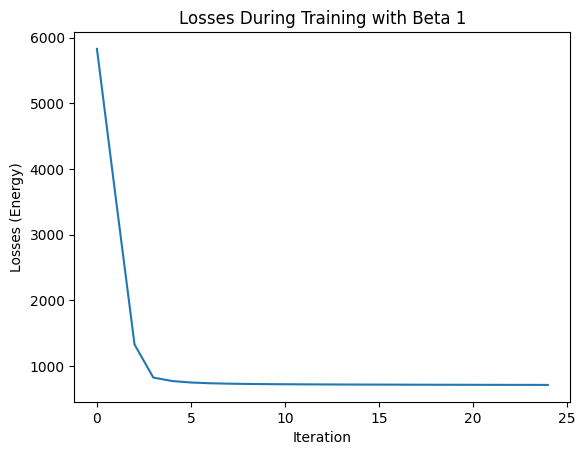

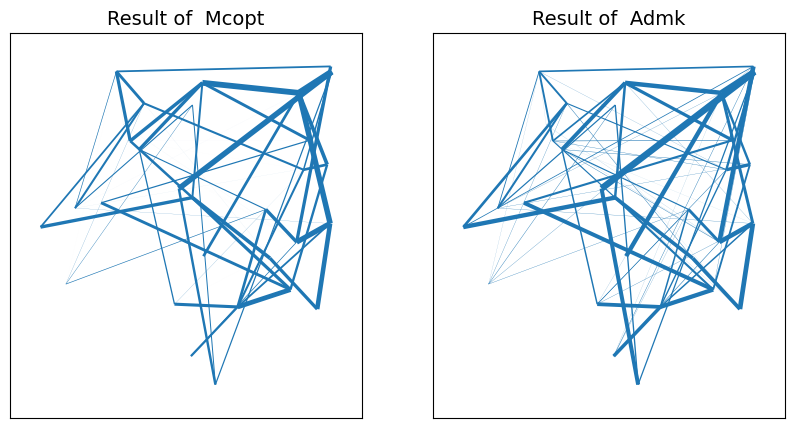

init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0002 max(res)=9.4e-09 max(pres)=7.9e-07
   -2.00e+00<=UPDATE<=5.72e+02, deltat=6.99e-03
ierr=0 avg_it=0002 max(res)=9.9e-09 max(pres)=9.0e-07
it=1 var=2.59e+01
   -1.99e+00<=UPDATE<=1.98e+02, deltat=7.05e-02
ierr=0 avg_it=0002 max(res)=9.4e-09 max(pres)=7.9e-07
it=2 var=8.25e+00
   -1.94e+00<=UPDATE<=5.85e+01, deltat=1.00e-01
ierr=0 avg_it=0002 max(res)=1.0e-08 max(pres)=9.1e-07
it=3 var=2.24e+00
   -2.13e+00<=UPDATE<=4.11e+01, deltat=1.00e-01
ierr=0 avg_it=0002 max(res)=9.9e-09 max(pres)=9.5e-07
it=4 var=1.31e+00
   -2.37e+00<=UPDATE<=3.20e+01, deltat=1.00e-01
ierr=0 avg_it=0002 max(res)=9.6e-09 max(pres)=1.2e-06
it=5 var=9.11e-01
   -2.40e+00<=UPDATE<=2.60e+01, deltat=1.00e-01
ierr=0 avg_it=0002 max(res)=1.0e-08 max(pres)=7.6e-07
it=6 var=6.83e-01
   -2.38e+00<=

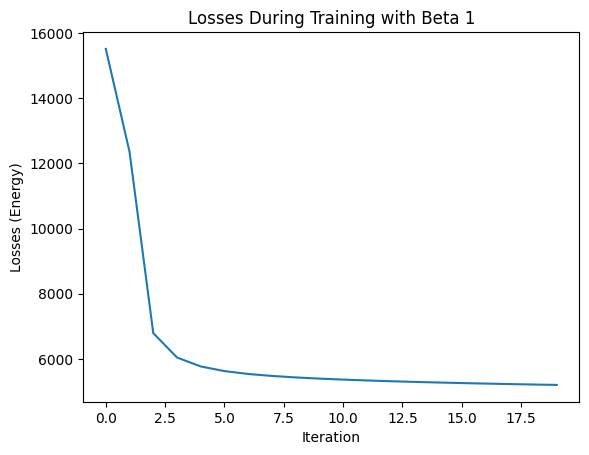

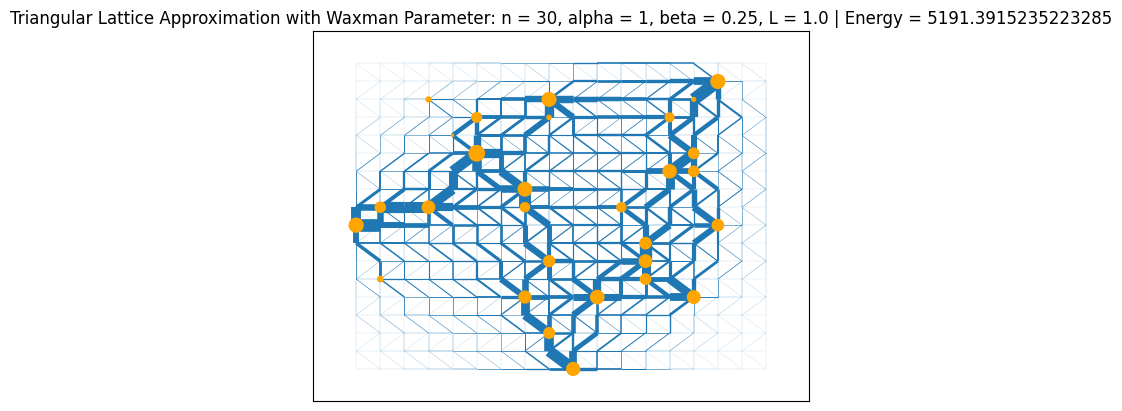

In [6]:
experiment_waxman_triangular_lattice()